In [1]:
import os
if os.getenv("COLAB_RELEASE_TAG"):
    import subprocess
    subprocess.run('wget https://raw.githubusercontent.com/luigibonati/mlcolvar/main/colab_setup.sh', shell=True)
    cmd = subprocess.run('bash colab_setup.sh TUTORIAL', shell=True, stdout=subprocess.PIPE)
    print(cmd.stdout.decode('utf-8'))

# IMPORT PACKAGES
import torch
import lightning
import numpy as np
import matplotlib.pyplot as plt

# IMPORT HELPER FUNCTIONS
from mlcolvar.utils.plot import muller_brown_potential, plot_isolines_2D, plot_metrics

# Set seed for reproducibility
torch.manual_seed(42)

/home/sompriya/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
import pandas as pd
from mlcolvar.utils.io import load_dataframe
from mlcolvar.utils.timelagged import create_timelagged_dataset
from mlcolvar.data import DictModule
import numpy as np


df = load_dataframe('COLVAR_multiT_new',start=10000,stop=100000)
df

/home/sompriya/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/sompriya/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


,time,lassoCV_node0,lassoCV_node1,ene,ecv.ene,opes.bias,cos1,cos2,cos3,cos4,...,cos16,cos17,cos18,cos19,cos20,cos21,cos22,cos23,cos24,walker
0,10000.000475,0.377827,-0.214888,-77438.289062,-77438.289062,4.766151,0.616939,0.042167,-0.998512,-0.915357,...,0.136094,-0.994362,0.740052,-0.581407,-0.517348,-0.965162,0.564225,-0.555500,-0.589475,0
1,10001.000475,0.423079,-0.198000,-76952.148438,-76952.148438,-10.796564,0.312993,0.243176,-0.999814,-0.959190,...,0.202523,-0.996790,0.723366,-0.990650,-0.278477,-0.939954,0.605292,-0.814105,-0.587153,0
2,10002.000475,0.483755,-0.169422,-76664.492188,-76664.492188,-39.680392,0.610573,0.377462,-0.983769,-0.955805,...,0.101025,-0.999146,0.648049,-0.914470,-0.345411,-0.943781,0.468034,-0.668371,-0.691890,0
3,10003.000475,0.483939,-0.251412,-76614.414062,-76614.414062,-46.352642,0.392321,0.372764,-0.998821,-0.981019,...,0.293319,-0.967217,0.496977,-0.913522,-0.815806,-0.998921,0.808226,-0.836520,-0.595694,0
4,10004.000475,0.477950,-0.234869,-76839.898438,-76839.898438,-20.120931,0.521642,0.037387,-0.988065,-0.950784,...,0.276645,-0.999621,0.477755,-0.914372,-0.131863,-0.908835,0.351647,-0.769502,-0.619501,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89995,99995.004750,0.466471,-0.293992,-76133.515625,-76133.515625,-129.676708,0.663620,0.383059,-0.996118,-0.271510,...,0.101746,-0.999241,0.137543,-0.715977,0.342481,-0.999880,0.277185,-0.925499,-0.559995,0
89996,99996.004750,0.352789,-0.240311,-76466.945312,-76466.945312,-67.296803,0.566846,0.060424,-0.848664,0.147212,...,0.031148,-0.990040,0.344758,-0.852722,0.323772,-0.981304,0.274755,-0.798690,-0.781918,0
89997,99997.004750,0.415323,-0.343453,-77344.101562,-77344.101562,4.232293,0.724438,0.137548,-0.884988,0.290771,...,0.076529,-0.967919,0.128228,-0.903186,0.065589,-0.987831,0.507524,-0.805677,-0.430118,0
89998,99998.004750,0.443725,-0.368171,-77579.359375,-77579.359375,4.987731,0.527356,0.190073,-0.935432,0.215633,...,0.202835,-0.998996,0.178790,-0.863268,0.390566,-0.996370,0.434321,-0.804828,-0.557249,0


In [3]:
# Select input features
X = df.filter(regex='cos').values
n_input = X.shape[1]

print(X.shape)
print(X)

(90000, 24)
[[ 0.616939  0.042167 -0.998512 ...  0.564225 -0.5555   -0.589475]
 [ 0.312993  0.243176 -0.999814 ...  0.605292 -0.814105 -0.587153]
 [ 0.610573  0.377462 -0.983769 ...  0.468034 -0.668371 -0.69189 ]
 ...
 [ 0.724438  0.137548 -0.884988 ...  0.507524 -0.805677 -0.430118]
 [ 0.527356  0.190073 -0.935432 ...  0.434321 -0.804828 -0.557249]
 [ 0.412321  0.386082 -0.927175 ...  0.323802 -0.720412 -0.403221]]


In [4]:
#------------- PARAMETERS -------------
multicanonical    = True
temp              = 275.
temp0             = 275.
#--------------------------------------

# Calculate inverse temperature
kb=0.008314
beta=1./(kb*temp)
beta0=1./(kb*temp0)

# Extract cvs from df

t = df['time'].values # save time
ene = df['ene'].values.astype(np.float64) # store energy as long double
bias = df.filter(regex='.bias').values.sum(axis=1) # Load *.bias columns and sum them

# Compute log-weights for time reweighting
logweights = beta*bias

if multicanonical:
    ene -= np.mean(ene) #first shift energy by its mean value
    logweights += (beta0-beta)*ene

In [5]:
#------------- PARAMETERS -------------
lag_time = 100.
#--------------------------------------

# create dataset
dataset = create_timelagged_dataset(X,t,lag_time=lag_time,logweights=logweights,progress_bar=True)
#dataset = create_timelagged_dataset(X,t,lag_time=lag_time,progress_bar=True)

# create datamodule (split train valid)
datamodule = DictModule(dataset,lengths=[0.8,0.2],random_split=False,shuffle=False)

datamodule

100%|████████████████████████████████████| 89693/89693 [06:17<00:00, 237.44it/s]
/home/sompriya/.local/lib/python3.10/site-packages/mlcolvar/utils/timelagged.py:186: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:275.)
  x_t = torch.stack(x_t) if type(x) == torch.Tensor else torch.Tensor(x_t)
/home/sompriya/.local/lib/python3.10/site-packages/mlcolvar/data/datamodule.py:134: UserWarning: A torch.generator was provided but it is not used with random_split=False
  warnings.warn(


DictModule(dataset -> DictDataset( "data": [178992, 24], "data_lag": [178992, 24], "weights": [178992], "weights_lag": [178992] ),
		     train_loader -> DictLoader(length=0.8, batch_size=0, shuffle=False),
		     valid_loader -> DictLoader(length=0.2, batch_size=0, shuffle=False))

In [6]:
from mlcolvar.cvs import DeepTICA

n_components = 2
nn_layers = [n_input, 16, 12, n_components]
options= {'nn': {'activation': 'shifted_softplus'}}

model = DeepTICA(nn_layers, options=options)
model

DeepTICA(
  (loss_fn): ReduceEigenvaluesLoss()
  (norm_in): Normalization(in_features=24, out_features=24, mode=mean_std)
  (nn): FeedForward(
    (nn): Sequential(
      (0): Linear(in_features=24, out_features=16, bias=True)
      (1): Shifted_Softplus(beta=1, threshold=20)
      (2): Linear(in_features=16, out_features=12, bias=True)
      (3): Shifted_Softplus(beta=1, threshold=20)
      (4): Linear(in_features=12, out_features=2, bias=True)
    )
  )
  (tica): TICA(in_features=2, out_features=2)
)

In [7]:
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from mlcolvar.utils.trainer import MetricsCallback

# define callbacks
metrics = MetricsCallback()
early_stopping = EarlyStopping(monitor="valid_loss", min_delta=1e-3, patience=100)

# define trainer
trainer = lightning.Trainer(callbacks=[metrics, early_stopping],
                     max_epochs=None, logger=None, enable_checkpointing=False)

# fit
torch.set_float32_matmul_precision('medium')
trainer.fit( model, datamodule )

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/sompriya/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
/home/sompriya/.local/lib/python3.10/site-packages/lightning/pytorch/

Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

/home/sompriya/.local/lib/python3.10/site-packages/lightning/pytorch/loops/fit_loop.py:298: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |                                               | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

...

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

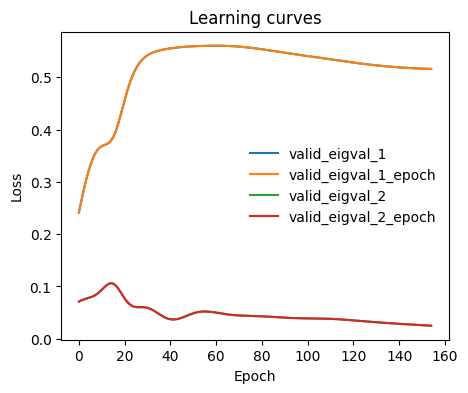

In [8]:
from mlcolvar.utils.plot import plot_metrics

ax = plot_metrics(metrics.metrics,
                  keys=[x for x in  metrics.metrics.keys() if 'valid_eigval' in x],#['train_loss_epoch','valid_loss'],
                  #linestyles=['-.','-'], colors=['fessa1','fessa5'],
                  yscale='linear')

In [9]:
from mlcolvar.core.transform import Normalization
from mlcolvar.core.transform.utils import Statistics

#X = dataset[:]['data']
with torch.no_grad():
    model.postprocessing = None # reset
    s = model(torch.Tensor(X))

norm =  Normalization(n_components, mode='min_max', stats = Statistics(s) )
model.postprocessing = norm

Text(0, 0.5, 'Deep-TICA 2')

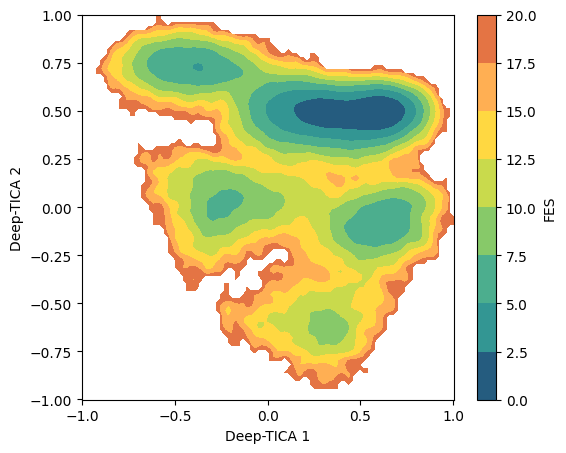

In [10]:
from mlcolvar.utils.fes import compute_fes

fig,ax = plt.subplots(1,1,figsize=(6,5),dpi=100)

# compute cvs
with torch.no_grad():
    s = model(torch.Tensor(X)).numpy()

w = np.exp(logweights)
fes,grid,bounds,error = compute_fes(s,
                                    blocks=1, #weights=w,
                                    bandwidth=0.01, scale_by='range',
                                    plot=True, plot_max_fes=20, ax = ax, eps=1e-8)

ax.set_xlabel('Deep-TICA 1') 
ax.set_ylabel('Deep-TICA 2')
#plt.savefig('Deep_TICA_multiT_aaaa_mod.png',dpi=300,bbox_inches='tight')

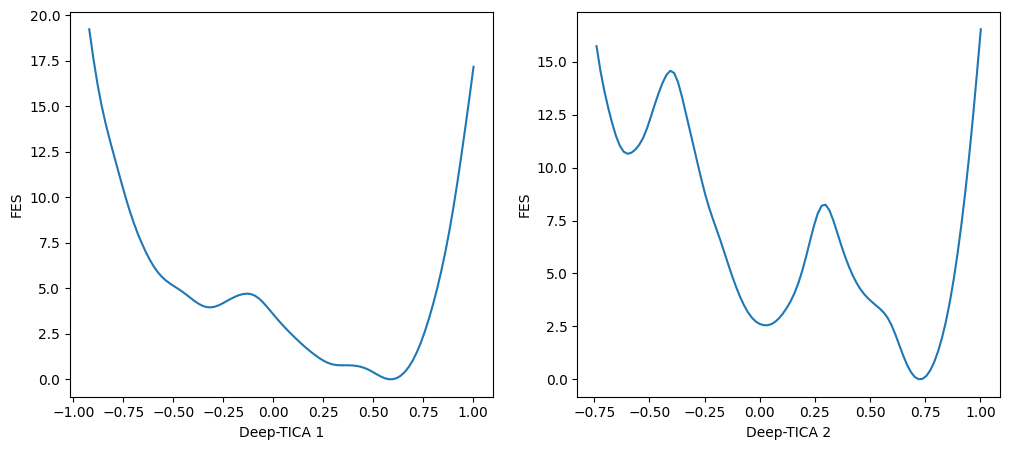

In [11]:
from mlcolvar.utils.fes import compute_fes

fig,axs = plt.subplots(1,n_components,figsize=(6*n_components,5),dpi=100)

for i in range(n_components):
    #w = np.exp(logweights)

    # restrict the second CV to the points in which the first is < 0
    fes,grid,bounds,error = compute_fes(s[:,i] if i == 0 else s[s[:,0] < 0, i ],
                                        #weights=w if i == 0 else w[s[:,0] < 0 ],
                                        blocks=1,
                                        bandwidth=0.02,scale_by='range',
                                        plot=True, plot_max_fes=20, ax = axs[i])
    axs[i].set_xlabel('Deep-TICA '+str(i+1))

In [12]:
## Save the model
x = torch.rand(n_input, dtype=torch.float32, requires_grad=True).unsqueeze(0)
traced_cv = torch.jit.trace ( model, example_inputs=x)
filename='rna_tetra_mutiT_deeptica_uuuu_mod.pt'
traced_cv.save(filename)

/home/sompriya/.local/lib/python3.10/site-packages/mlcolvar/core/nn/utils.py:13: TracerWarning: Converting a tensor to a Python number might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  sp0 = F.softplus(torch.zeros(1), self.beta, self.threshold).item()
/home/sompriya/.local/lib/python3.10/site-packages/torch/jit/_trace.py:165: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at aten/src/ATen/core/TensorBody.h:489.)
  if a.grad is n

In [13]:
#Lasso Regression delete low weitage NN
from sklearn import linear_model
from sklearn.linear_model import LassoCV

with torch.no_grad():
    s = model(torch.Tensor(X)).numpy()
tic0 = s[:,0]#select DeepTICA 1

reg0 = LassoCV(cv=5, random_state=0, max_iter=10000).fit(X, tic0)
print(reg0.coef_)
print(reg0.intercept_)
np.savetxt('tica1_coeff.txt',reg0.coef_,fmt='%0.3f')

[ 0.01070843  0.02238632 -0.00853716  0.02673619 -0.         -0.03687953
  0.06657997 -0.07333565  0.20626194 -0.14909084  0.05111268 -0.02343591
 -0.0165393  -0.09667496  0.46350355  0.2034399  -0.0261338   0.02733448
  0.01770842 -0.01236004 -0.05392613  0.28289394 -0.00049033 -0.00823209]
-0.109257686138298


In [14]:
#Lasso Regression delete low weitage NN
from sklearn import linear_model
from sklearn.linear_model import LassoCV

with torch.no_grad():
    s = model(torch.Tensor(X)).numpy()
tic1 = s[:,1]#select DeepTICA 2

reg1 = LassoCV(cv=5, random_state=0, max_iter=10000).fit(X, tic1)
print(reg1.coef_)
print(reg1.intercept_)
np.savetxt('tica2_coeff.txt',reg1.coef_,fmt='%0.3f')

[ 0.01507074  0.017987   -0.01251548 -0.00210915  0.00127913 -0.03666405
 -0.00044224  0.38172426  0.0179609   0.02199551  0.00649574 -0.00989436
 -0.01688693 -0.00642756 -0.17408909 -0.01429182 -0.02405488 -0.0120885
 -0.          0.00406897 -0.08050762  0.2810912   0.00817116 -0.00545316]
0.12294950814631206


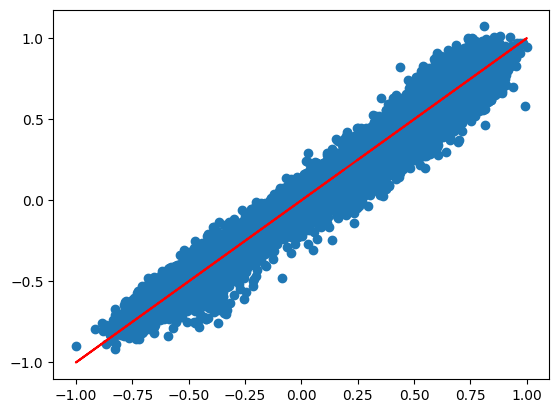

In [15]:
X_np = torch.Tensor(X).numpy()
ypred = reg0.predict(X)

plt.scatter(tic0,ypred)
plt.plot(tic0,tic0,c='r') # X axis=DeepTICA 1 CV, Y axis= lassoCV, 

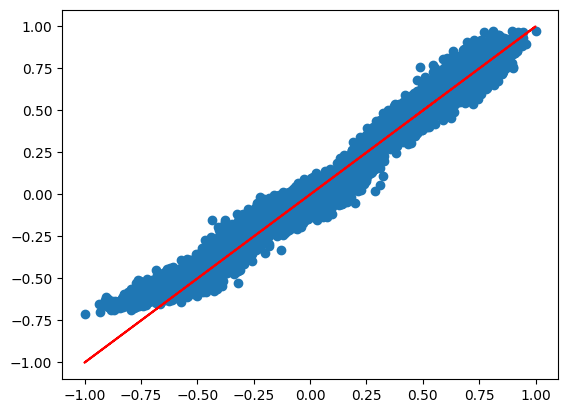

In [16]:
X_np = torch.Tensor(X).numpy()
ypred = reg1.predict(X)

plt.scatter(tic1,ypred)
plt.plot(tic1,tic1,c='r') # X axis=DeepTICA 2 CV, Y axis= lassoCV, 

In [17]:
s='lasso_node0: COMBINE ARG='
for i in range(len(reg0.coef_)):
    if reg0.coef_[i] != 0:
        s+= 'cos%d'%(i+1)
        if i < len(reg0.coef_) - 1:
            s+= ','
s+= ' COEFFICIENTS='

for i in range(len(reg0.coef_)):
    if reg0.coef_[i] != 0:
        s+= '%0.4f'%reg0.coef_[i]
        if i < len(reg0.coef_) - 1:
            s+= ','
s+= ' PERIODIC=NO'
print(s)
print(' ')

#correct for offset
of_arr = ypred - np.dot(X_np,reg0.coef_)
offset = reg0.intercept_
if offset>0:
    s2 = 'lassoCV_node0: MATHEVAL ARG=lasso_node0 FUNC=x+%0.4f PERIODIC=NO'%offset
elif offset<0:
    s2 = 'lassoCV_node0: MATHEVAL ARG=lasso_node0 FUNC=x%0.4f PERIODIC=NO'%offset
print(s2)

lasso_node0: COMBINE ARG=cos1,cos2,cos3,cos4,cos6,cos7,cos8,cos9,cos10,cos11,cos12,cos13,cos14,cos15,cos16,cos17,cos18,cos19,cos20,cos21,cos22,cos23,cos24 COEFFICIENTS=0.0107,0.0224,-0.0085,0.0267,-0.0369,0.0666,-0.0733,0.2063,-0.1491,0.0511,-0.0234,-0.0165,-0.0967,0.4635,0.2034,-0.0261,0.0273,0.0177,-0.0124,-0.0539,0.2829,-0.0005,-0.0082 PERIODIC=NO
 
lassoCV_node0: MATHEVAL ARG=lasso_node0 FUNC=x-0.1093 PERIODIC=NO


In [18]:
s='lasso_node1: COMBINE ARG='
for i in range(len(reg1.coef_)):
    if reg1.coef_[i] != 0:
        s+= 'cos%d'%(i+1)
        if i < len(reg1.coef_) - 1:
            s+= ','
s+= ' COEFFICIENTS='

for i in range(len(reg1.coef_)):
    if reg1.coef_[i] != 0:
        s+= '%0.4f'%reg1.coef_[i]
        if i < len(reg1.coef_) - 1:
            s+= ','
s+= ' PERIODIC=NO'
print(s)
print(' ')

#correct for offset
of_arr = ypred - np.dot(X_np,reg1.coef_)
offset = reg1.intercept_
if offset>0:
    s2 = 'lassoCV_node1: MATHEVAL ARG=lasso_node1 FUNC=x+%0.4f PERIODIC=NO'%offset
elif offset<0:
    s2 = 'lassoCV_node1: MATHEVAL ARG=lasso_node1 FUNC=x%0.4f PERIODIC=NO'%offset
print(s2)

lasso_node1: COMBINE ARG=cos1,cos2,cos3,cos4,cos5,cos6,cos7,cos8,cos9,cos10,cos11,cos12,cos13,cos14,cos15,cos16,cos17,cos18,cos20,cos21,cos22,cos23,cos24 COEFFICIENTS=0.0151,0.0180,-0.0125,-0.0021,0.0013,-0.0367,-0.0004,0.3817,0.0180,0.0220,0.0065,-0.0099,-0.0169,-0.0064,-0.1741,-0.0143,-0.0241,-0.0121,0.0041,-0.0805,0.2811,0.0082,-0.0055 PERIODIC=NO
 
lassoCV_node1: MATHEVAL ARG=lasso_node1 FUNC=x+0.1229 PERIODIC=NO
